In [169]:
# Importing Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [170]:
data = pd.read_csv('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/data-set/bank-full.csv',sep=";",quotechar='"')

In [171]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [172]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [173]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [174]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


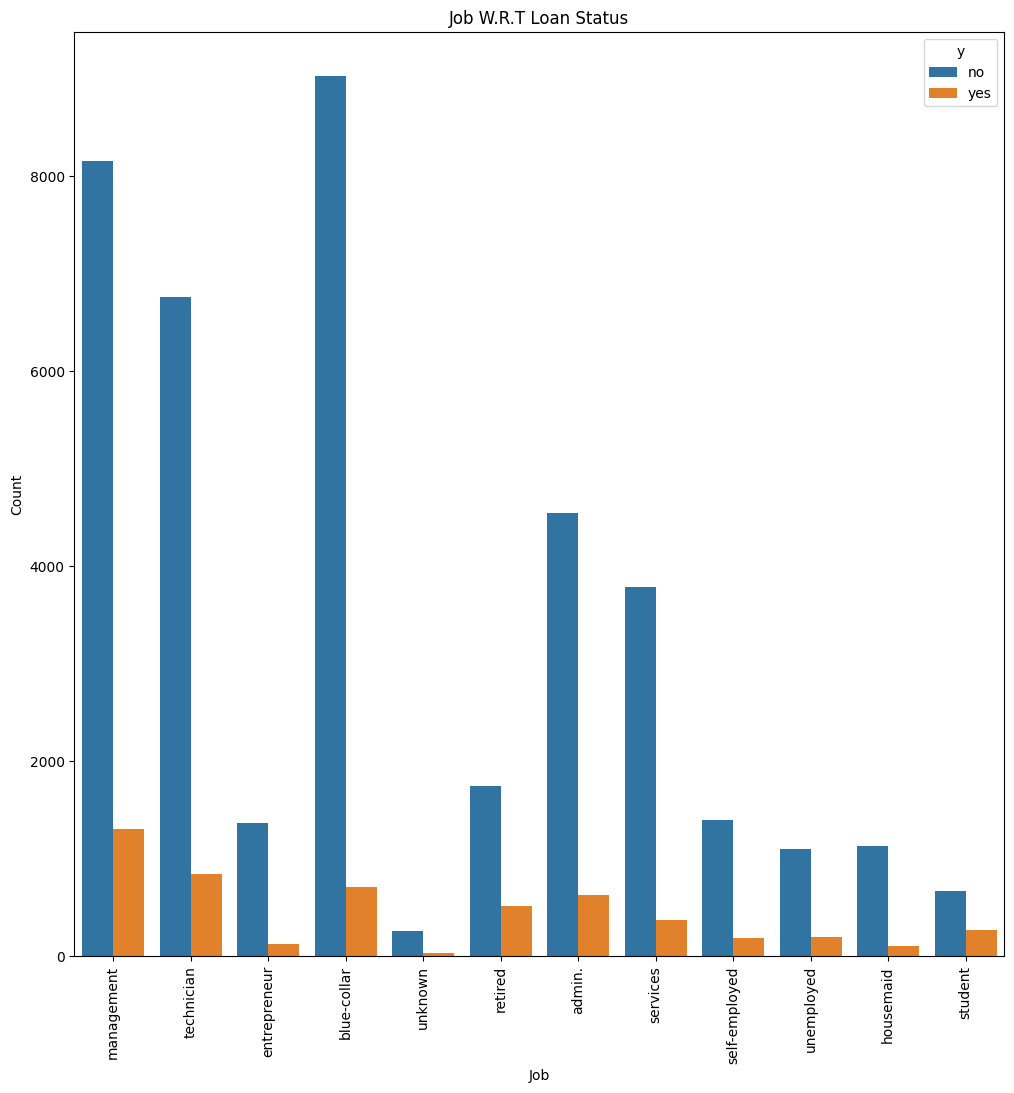

In [175]:
plt.figure(figsize=(12,12))
sns.countplot(data=data,x='job',hue='y')
plt.xticks(rotation=90)
plt.title('Job W.R.T Loan Status')
plt.xlabel('Job')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Job W.R.T Loan Status.png')
plt.show()

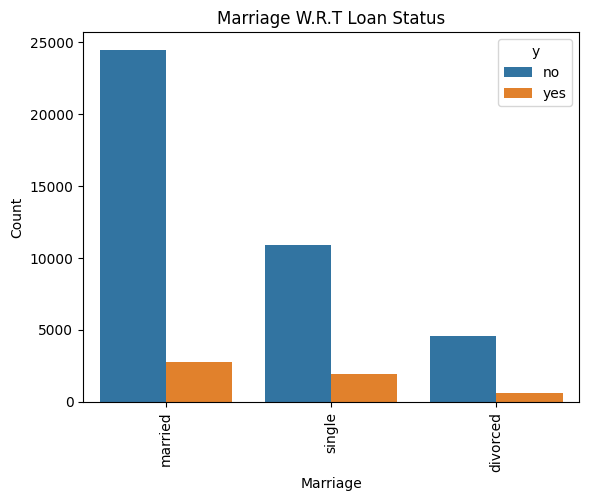

In [176]:
sns.countplot(data=data,x='marital',hue='y')
plt.xticks(rotation=90)
plt.title('Marriage W.R.T Loan Status')
plt.xlabel('Marriage')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Marriage W.R.T Loan Status.png')
plt.show()

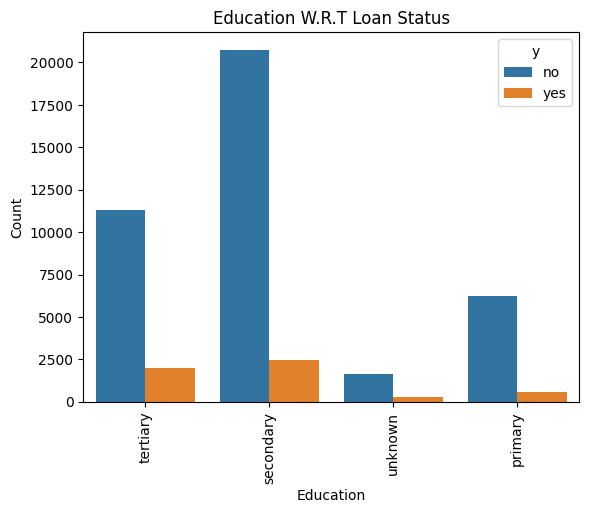

In [177]:
sns.countplot(data=data,x='education',hue='y')
plt.xticks(rotation=90)
plt.title('Education W.R.T Loan Status')
plt.xlabel('Education')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Education W.R.T Loan Status.png')
plt.show()

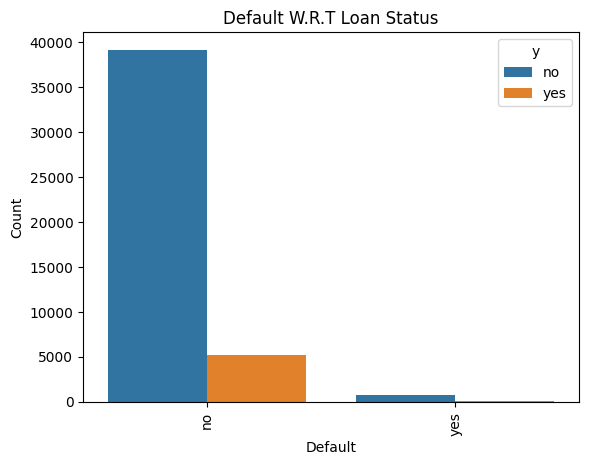

In [178]:
sns.countplot(data=data,x='default',hue='y')
plt.xticks(rotation=90)
plt.title('Default W.R.T Loan Status')
plt.xlabel('Default')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Default W.R.T Loan Status.png')
plt.show()

In [179]:
data['balance_status'] = data.balance.apply(lambda x : 'Negative' if 0 > x else 'Low' if 0 <= x < 1000 else 'Medium' if  1000 <= x <50000 else 'High' if 50000 <= x < 120000  else np.nan)

In [180]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_status
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,Medium
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,Low
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,Low
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,Medium
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,Low
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,Medium
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,Medium
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,Low


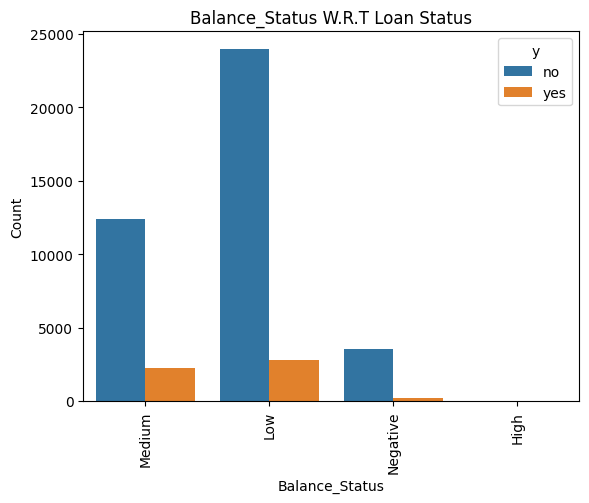

In [181]:
sns.countplot(data=data,x='balance_status',hue='y')
plt.xticks(rotation=90)
plt.title('Balance_Status W.R.T Loan Status')
plt.xlabel('Balance_Status')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Balance_Status W.R.T Loan Status.png')
plt.show()

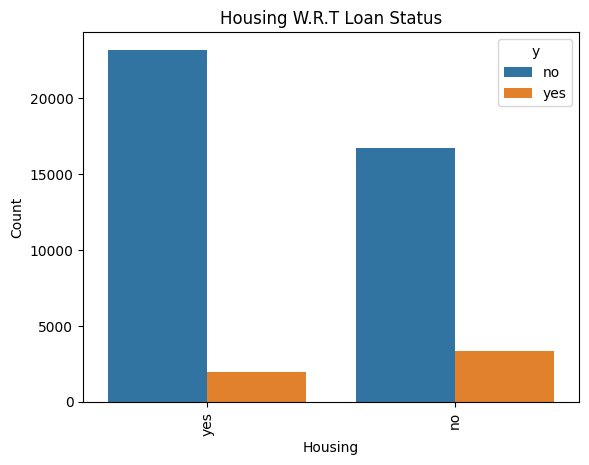

In [182]:
sns.countplot(data=data,x='housing',hue='y')
plt.xticks(rotation=90)
plt.title('Housing W.R.T Loan Status')
plt.xlabel('Housing')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Housing W.R.T Loan Status.png')
plt.show()

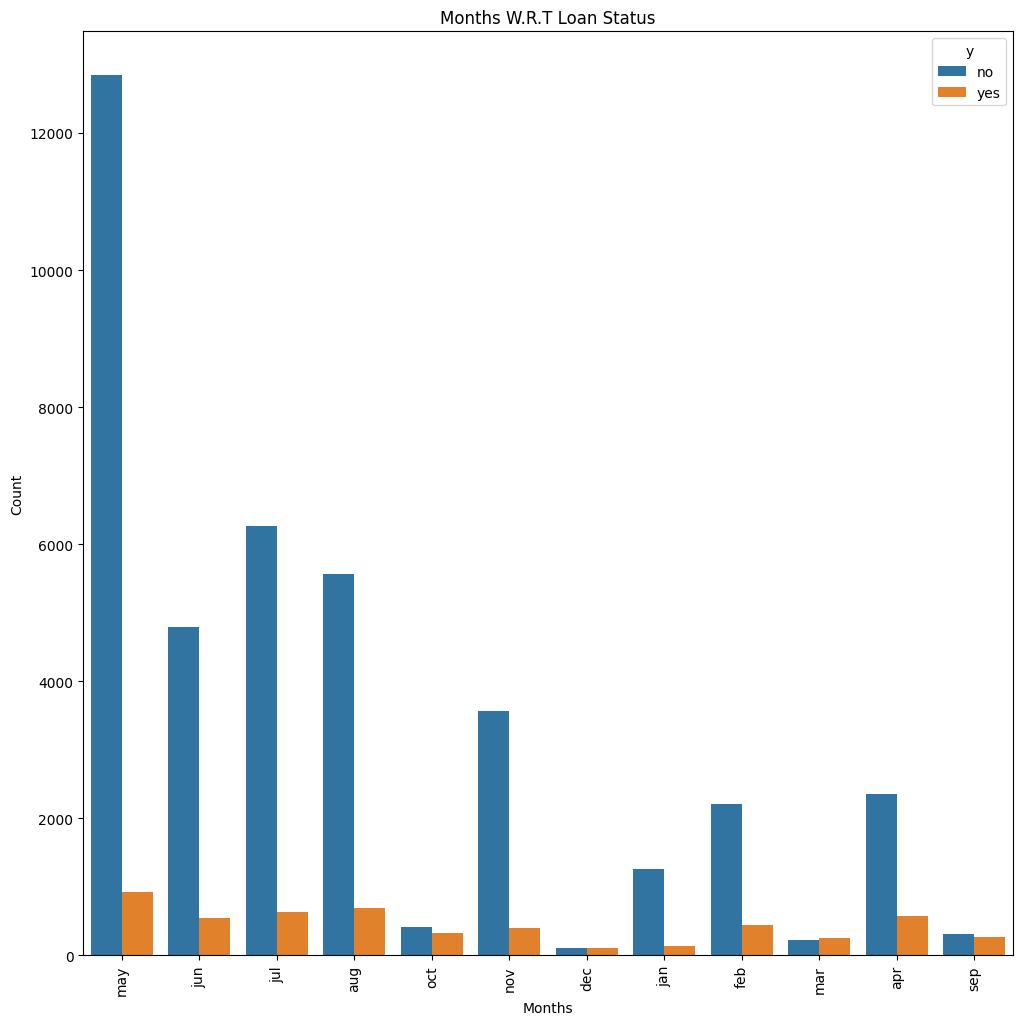

In [183]:
plt.figure(figsize=(12,12))
sns.countplot(data=data,x='month',hue='y')
plt.xticks(rotation=90)
plt.title('Months W.R.T Loan Status')
plt.xlabel('Months')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Months W.R.T Loan Status.png')
plt.show()

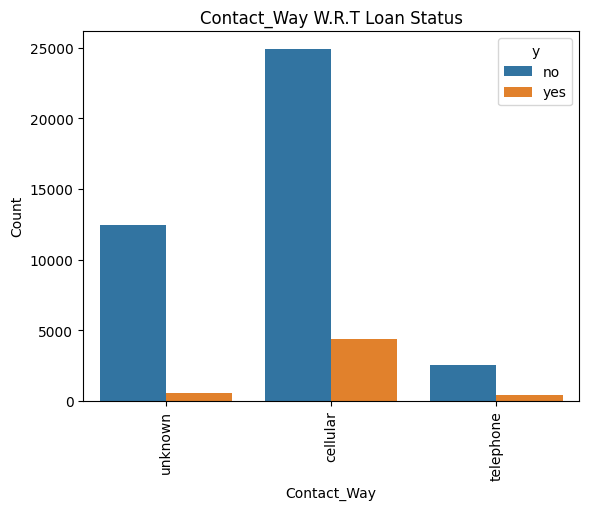

In [184]:
sns.countplot(data=data,x='contact',hue='y')
plt.xticks(rotation=90)
plt.title('Contact_Way W.R.T Loan Status')
plt.xlabel('Contact_Way')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Contact_Way W.R.T Loan Status.png')
plt.show()

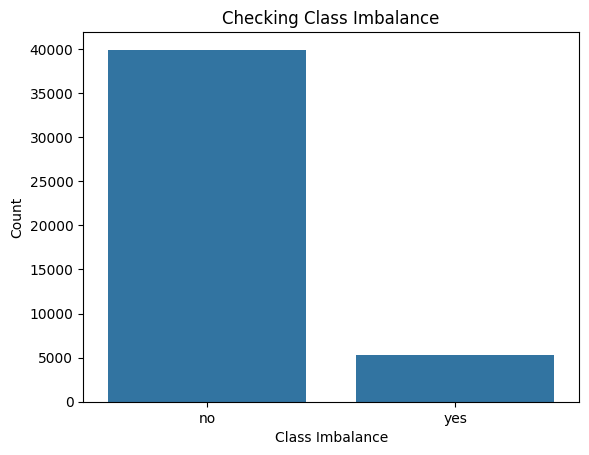

In [185]:
sns.countplot(data=data,x='y')
plt.title('Checking Class Imbalance')
# plt.xticks(rotation=90)
# plt.title('Class Imbalance W.R.T Loan Status')
plt.xlabel('Class Imbalance')
plt.ylabel('Count')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Class Imbalance.png')
plt.show()

In [186]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_status
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,Medium
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,Low
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,Low
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,Medium
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,Low
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,Medium
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,Medium
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,Low


<Axes: xlabel='age', ylabel='Count'>

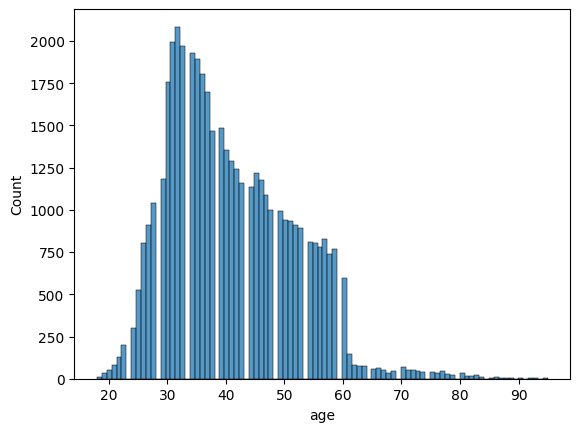

In [187]:
sns.histplot(data=data,x='age')

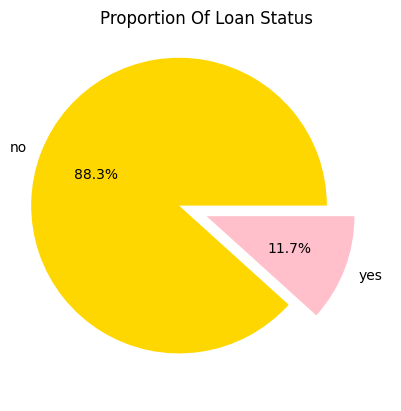

In [188]:
data['y'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=['gold','pink'],explode=[0.2,0])
plt.title('Proportion Of Loan Status')
plt.savefig('/home/aliqamar/Desktop/Data_Science-Internship-Projects-/data-science-internship-projects/Task-5-Loan-Acceptance/images/Proportion Of Loan.png')
plt.show()

<Axes: xlabel='job'>

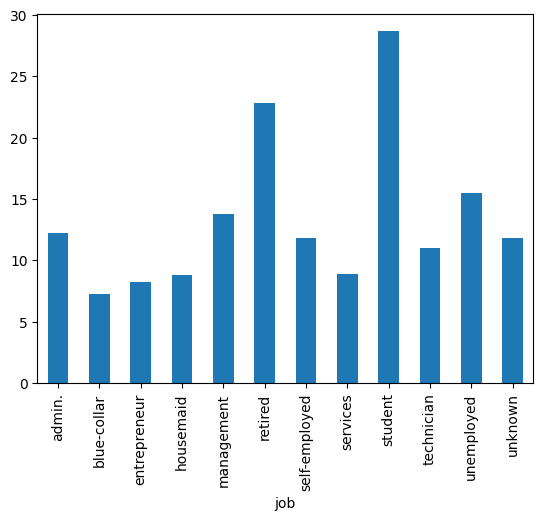

In [189]:
total = data['job'].value_counts()
yes = data[data['y']=='yes']['job'].value_counts()
conversion_rate = (yes/total).fillna(0)*100
conversion_rate.plot(kind='bar')

<Axes: xlabel='marital'>

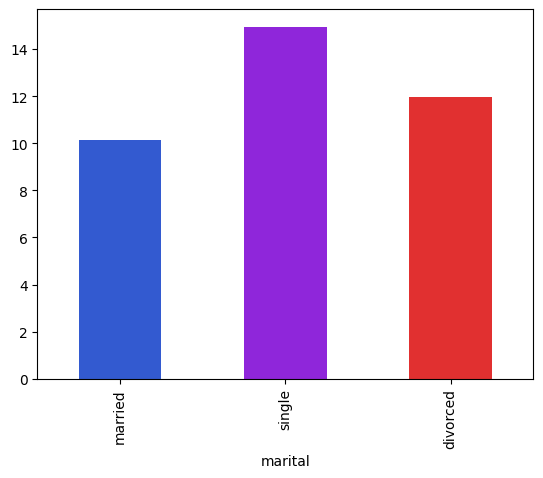

In [190]:
total = data.marital.value_counts()
yes = data[data['y']=='yes']['marital'].value_counts()
proportion = (yes/total).fillna(0)*100
proportion.plot(kind='bar',color = [
    "#335AD0",  # Royal Blue 🔵
    "#8F26DA",  # Purple Dream 🟣
    "#E13030",  # Neon Red 🔥
])

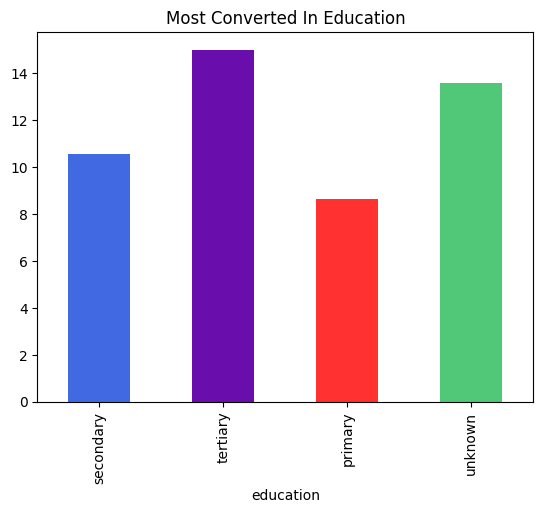

In [191]:
total = data.education.value_counts()
yes = data[data['y']=='yes']['education'].value_counts()
proportion = (yes/total)*100
proportion.plot(kind='bar',color = [
    "#4169E1",  # Royal Blue 🔵
    "#6A0DAD",  # Purple Dream 🟣
    "#FF3131",  # Neon Red 🔥
    "#50C878",  # Emerald Green 🟢
    "#FFD700"   # Golden Yellow 💛
])
plt.title('Most Converted In Education')
plt.show()

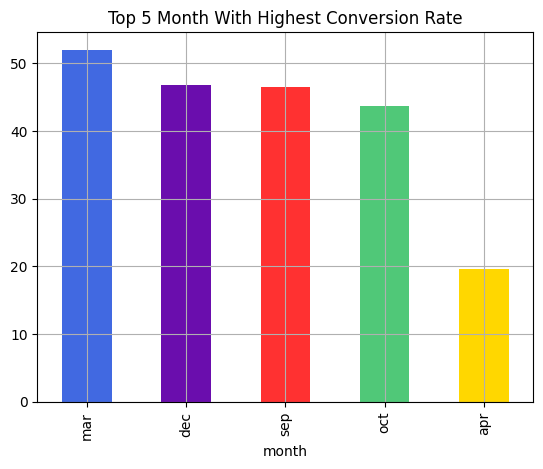

In [192]:
total = data['month'].value_counts()
yes = data[data['y']=='yes']['month'].value_counts()
proportion = (yes/total)*100
proportion.sort_values(ascending=False).head().plot(kind='bar',color = [
    "#4169E1",  # Royal Blue 
    "#6A0DAD",  # Purple Dream 
    "#FF3131",  # Neon Red 
    "#50C878",  # Emerald Green 
    "#FFD700"   # Golden Yellow 
])
plt.title('Top 5 Month With Highest Conversion Rate')
plt.grid()
plt.show()

In [193]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_status
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,Medium
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,Low
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,Low
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,Medium
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes,Low
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes,Medium
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes,Medium
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no,Low


In [194]:
data['y'] = data['y'].map({'yes':1,'no':0})

In [195]:
X = data.drop('y',axis=1)
y = data['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [196]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_status
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,Medium
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,Low
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,Low
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,Medium
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,1,Low
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,1,Medium
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,1,Medium
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,0,Low


In [197]:
# Column Transformer
numerical_column = ['age','balance','duration',]
categoral_column = ['job','marital','education','default','housing','loan','contact','poutcome','balance_status']


In [198]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_column),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoral_column)
    ]
)


In [199]:
# Logistic Regression
model_logic = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
model_logic.fit(X_train,y_train)
predict_logistic = model_logic.predict(X_test)


In [200]:
print(f'''
      Logistic
Accuracy{accuracy_score(y_test,predict_logistic)}
Precision{precision_score(y_test,predict_logistic)}
Recall{recall_score(y_test,predict_logistic)}''')


      Logistic
Accuracy0.8981532677208891
Precision0.6539855072463768
Recall0.3308890925756187


In [201]:
# Decision Tree
DecisionTreeClassifier_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])
DecisionTreeClassifier_model.fit(X_train,y_train)
predict_decision_tree = DecisionTreeClassifier_model.predict(X_test)


In [202]:
print(f'''
      Decision
Accuracy{accuracy_score(y_test,predict_decision_tree)}
Precision{precision_score(y_test,predict_decision_tree)}
Recall{recall_score(y_test,predict_decision_tree)}''')


      Decision
Accuracy0.8571270596041137
Precision0.41417591801878734
Recall0.44454628780934924


In [203]:
# Random Forest
RandomForestClassifier_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
RandomForestClassifier_model.fit(X_train,y_train)
predict_random_forest = RandomForestClassifier_model.predict(X_test)


In [205]:
print(f'''
      Random Forest
Accuracy{accuracy_score(y_test,predict_random_forest)}
Precision{precision_score(y_test,predict_random_forest)}
Recall{recall_score(y_test,predict_random_forest)}''')


      Random Forest
Accuracy0.8974897710936636
Precision0.628125
Recall0.3684692942254812
